In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

DRIVE_ROOT    = '/content/drive/MyDrive/BenderTest'
IMAGES_DIR    = os.path.join(DRIVE_ROOT, 'images')
TEMPLATES_DIR = os.path.join(DRIVE_ROOT, 'templates')
EXCEL_PATH    = os.path.join(DRIVE_ROOT, 'bender_gestalt_reveiws.xlsx')
OUTPUT_DIR    = os.path.join(DRIVE_ROOT, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Imports

In [3]:
import glob, re
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter
import torch

---
# PART 2 — MACHINE LEARNING PIPELINE

## Load psychologist Excel & explore

In [ ]:
df_psych = pd.read_excel(EXCEL_PATH)
print(f'Excel shape: {df_psych.shape}')
print('Columns:', list(df_psych.columns))
df_psych.head(3)

Excel shape: (89, 15)
Columns: ['رقم الحالة', 'الاسم', 'النوع', 'الصف الدراسي', 'العمر', 'التسلسل', 'موضع الرسم', 'المسافة بين رسمين', 'الاتصال أو التصادم', 'استخدام الهامش', 'تغيير موضع الورقة', 'التغيرات في الجشطالت', 'ملاحظات دالة بشكل عام', 'التصنيفات المرضية', 'التعليق العام']


,رقم الحالة,الاسم,النوع,الصف الدراسي,العمر,التسلسل,موضع الرسم,المسافة بين رسمين,الاتصال أو التصادم,استخدام الهامش,تغيير موضع الورقة,التغيرات في الجشطالت,ملاحظات دالة بشكل عام,التصنيفات المرضية,التعليق العام
0,1,ياسين محمود علي حسن,ذكر,الرابع الإبتدائي,9,تسلسل غير منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, التغير في الانحناءات",لا يوجد,سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...
1,2,عمرو احمد محمد فتحي,ذكر,الرابع الإبتدائي,9,تسلسل منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق - التغير في الانحناءات, التغير ...",إعادة رسم الأجزاء (خطوط ثقيلة),سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...
2,3,محمد سيد البدري عبد المطلب,ذكر,الرابع الإبتدائي,9,تسلسل غير منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, صعوبات التقاطع, التغير في الان...","اندفاع وسرعة في الرسم, المداومة",سوي,المفحوص بشكل عام سوي ويتمتع بمستوى متوسط من ال...


In [ ]:
df_psych = pd.read_excel(EXCEL_PATH)
print(f'Excel shape: {df_psych.shape}')
print('Columns:', list(df_psych.columns))
df_psych.head(3)

Excel shape: (89, 15)
Columns: ['رقم الحالة', 'الاسم', 'النوع', 'الصف الدراسي', 'العمر', 'التسلسل', 'موضع الرسم', 'المسافة بين رسمين', 'الاتصال أو التصادم', 'استخدام الهامش', 'تغيير موضع الورقة', 'التغيرات في الجشطالت', 'ملاحظات دالة بشكل عام', 'التصنيفات المرضية', 'التعليق العام']


,رقم الحالة,الاسم,النوع,الصف الدراسي,العمر,التسلسل,موضع الرسم,المسافة بين رسمين,الاتصال أو التصادم,استخدام الهامش,تغيير موضع الورقة,التغيرات في الجشطالت,ملاحظات دالة بشكل عام,التصنيفات المرضية,التعليق العام
0,1,ياسين محمود علي حسن,ذكر,الرابع الإبتدائي,9,تسلسل غير منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, التغير في الانحناءات",لا يوجد,سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...
1,2,عمرو احمد محمد فتحي,ذكر,الرابع الإبتدائي,9,تسلسل منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق - التغير في الانحناءات, التغير ...",إعادة رسم الأجزاء (خطوط ثقيلة),سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...
2,3,محمد سيد البدري عبد المطلب,ذكر,الرابع الإبتدائي,9,تسلسل غير منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, صعوبات التقاطع, التغير في الان...","اندفاع وسرعة في الرسم, المداومة",سوي,المفحوص بشكل عام سوي ويتمتع بمستوى متوسط من ال...


Diagnosis distribution:
التصنيفات المرضية
سوي              84
العصاب            3
التخلف العقلي     2
Name: count, dtype: int64


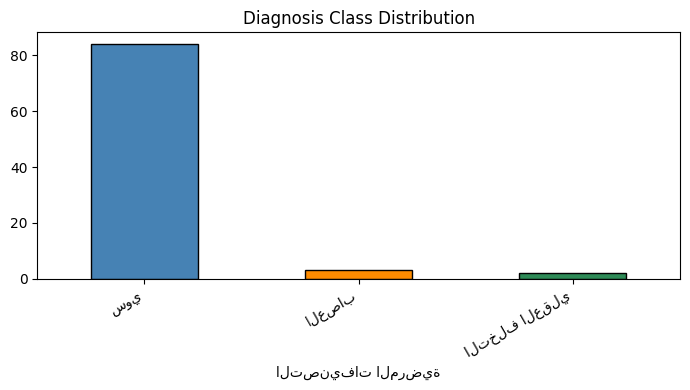

In [9]:
df_psych['التصنيفات المرضية'] = df_psych['التصنيفات المرضية'].str.strip()

print('Diagnosis distribution:')
print(df_psych['التصنيفات المرضية'].value_counts())

df_psych['التصنيفات المرضية'].value_counts().plot(
    kind='bar', color=['steelblue','darkorange','seagreen'],
    title='Diagnosis Class Distribution', edgecolor='black', figsize=(7,4)
)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'class_dist.png'), dpi=150)
plt.show()

## Feature Engineering (multi-value columns → binary flags)

In [10]:
import re

def explode_column(df, col, sep_pattern=r'[,،\-]+', prefix=None):

    if col not in df.columns:
        return df

    prefix = prefix or col

    split_col = (
        df[col].fillna('').astype(str)
               .str.strip()
               .apply(lambda v: [p.strip() for p in re.split(sep_pattern, v)
                                 if p.strip() and p.strip() != 'لا يوجد'])
    )

    all_vals = sorted({v for lst in split_col for v in lst})

    for val in all_vals:
        safe = re.sub(r'[^\w]', '_', val.strip())
        new_col = f'{prefix}__{safe}'
        df[new_col] = split_col.apply(lambda lst: int(val in lst))

    print(f'  "{col}" → {len(all_vals)} binary features')
    df.drop(columns=[col], inplace=True)
    return df


df_eng = df_psych.copy()

seq_map = {
    'تسلسل منظم':    3,   # organised
    'تسلسل ثابت':    2,   # stable
    'تسلسل مرتبك':   1,   # confused
    'تسلسل غير منظم':0,   # disorganised
}
df_eng['التسلسل_ordinal'] = df_eng['التسلسل'].map(seq_map).fillna(0).astype(int)
df_eng.drop(columns=['التسلسل'], inplace=True)

space_map = {
    'من 0.75 إلى 1.25 سم': 1,   # normal
    'مسافة صغيرة جداً':    0,   # too small
}
df_eng['المسافة_ordinal'] = df_eng['المسافة بين رسمين'].map(space_map).fillna(1).astype(int)
df_eng.drop(columns=['المسافة بين رسمين'], inplace=True)

coll_map = {
    'لا يوجد تداخل':      0,
    'تصادم أو نزعة إليه': 1,
    'تداخل الرسوم':       2,
}
df_eng['التصادم_ordinal'] = df_eng['الاتصال أو التصادم'].map(coll_map).fillna(0).astype(int)
df_eng.drop(columns=['الاتصال أو التصادم'], inplace=True)

df_eng['موضع_الرسم']       = (df_eng['موضع الرسم']        != 'لا').astype(int)
df_eng['استخدام_الهامش']   = (df_eng['استخدام الهامش']    != 'لا').astype(int)
df_eng['تغيير_موضع_الورقة'] = (df_eng['تغيير موضع الورقة'] == 'نعم').astype(int)
df_eng.drop(columns=['موضع الرسم','استخدام الهامش','تغيير موضع الورقة'], inplace=True)

df_eng['ذكر'] = (df_eng['النوع'] == 'ذكر').astype(int)
df_eng.drop(columns=['النوع'], inplace=True)

grade_map = {
    'الرابع الإبتدائي': 1,
    'السادس الإبتدائي': 2,
    'الأول إعدادى':     3,
    'الثالث إعدادى':    4,
}
df_eng['الصف_ordinal'] = df_eng['الصف الدراسي'].map(grade_map).fillna(1).astype(int)
df_eng.drop(columns=['الصف الدراسي'], inplace=True)

print('\nExploding multi-value columns:')
df_eng = explode_column(df_eng, 'التغيرات في الجشطالت',
                         sep_pattern=r'[,،]+')
df_eng = explode_column(df_eng, 'ملاحظات دالة بشكل عام',
                         sep_pattern=r'[,،]+')

df_eng.drop(columns=['الاسم', 'التعليق العام'], inplace=True, errors='ignore')

print('Columns:', list(df_eng.columns))


Exploding multi-value columns:
  "التغيرات في الجشطالت" → 13 binary features
  "ملاحظات دالة بشكل عام" → 8 binary features
Columns: ['رقم الحالة', 'العمر', 'التصنيفات المرضية', 'التسلسل_ordinal', 'المسافة_ordinal', 'التصادم_ordinal', 'موضع_الرسم', 'استخدام_الهامش', 'تغيير_موضع_الورقة', 'ذكر', 'الصف_ordinal', 'التغيرات في الجشطالت__التغير_في_الإنحناءات', 'التغيرات في الجشطالت__التغير_في_الانحناءات', 'التغيرات في الجشطالت__التغير_في_حجم_الزوايا', 'التغيرات في الجشطالت__التغير_في_حجم_الزوايا__صعوبة_رسم_الأشكال_المتداخلة', 'التغيرات في الجشطالت__تبسيط', 'التغيرات في الجشطالت__تبسيط_الرسم', 'التغيرات في الجشطالت__تجزئة_الجشطالت', 'التغيرات في الجشطالت__تدوير_محور_الرسم', 'التغيرات في الجشطالت__صعوبات_الإغلاق', 'التغيرات في الجشطالت__صعوبات_الإغلاق___التغير_في_الانحناءات', 'التغيرات في الجشطالت__صعوبات_التقاطع', 'التغيرات في الجشطالت__صعوبات_تقاطع', 'التغيرات في الجشطالت__صعوبة_رسم_الأشكال_المتداخلة', 'ملاحظات دالة بشكل عام__إعادة_رسم_الأجزاء__خطوط_ثقيلة_', 'ملاحظات دالة بشكل عام__استخدام_أ

## Merge CV features with engineered Excel & save

In [11]:
df_cv['case_number'] = pd.to_numeric(
    df_cv['student_id'].str.extract(r'(\d+)')[0], errors='coerce'
)
df_eng = df_eng.rename(columns={'رقم الحالة': 'case_number'})

df_full = df_eng.merge(df_cv, on='case_number', how='left')

# Save Part 1 output
PART1_OUT = os.path.join(OUTPUT_DIR, 'part1_engineered_features.xlsx')
df_full.to_excel(PART1_OUT, index=False)
print(f'Full dataset shape   : {df_full.shape}')
df_full.head(3)

Full dataset shape   : (89, 129)


,case_number,العمر,التصنيفات المرضية,التسلسل_ordinal,المسافة_ordinal,التصادم_ordinal,موضع_الرسم,استخدام_الهامش,تغيير_موضع_الورقة,ذكر,...,fig9_closure,fig9_pos_x,fig9_pos_y,fig9_scale,total_detected,total_erasures,mean_distortion,mean_abs_rotation,max_distortion,any_erasure
0,1,9,سوي,0,1,0,0,0,0,1,...,0.0,-1.0,-1.0,0.0,0,0,1.0,0.0,1.0,0
1,2,9,سوي,3,1,0,0,0,0,1,...,0.0,-1.0,-1.0,0.0,0,0,1.0,0.0,1.0,0
2,3,9,سوي,0,1,0,0,0,0,1,...,0.0,-1.0,-1.0,0.0,0,0,1.0,0.0,1.0,0


## EDA on the final feature set

/tmp/ipykernel_19884/2175897956.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


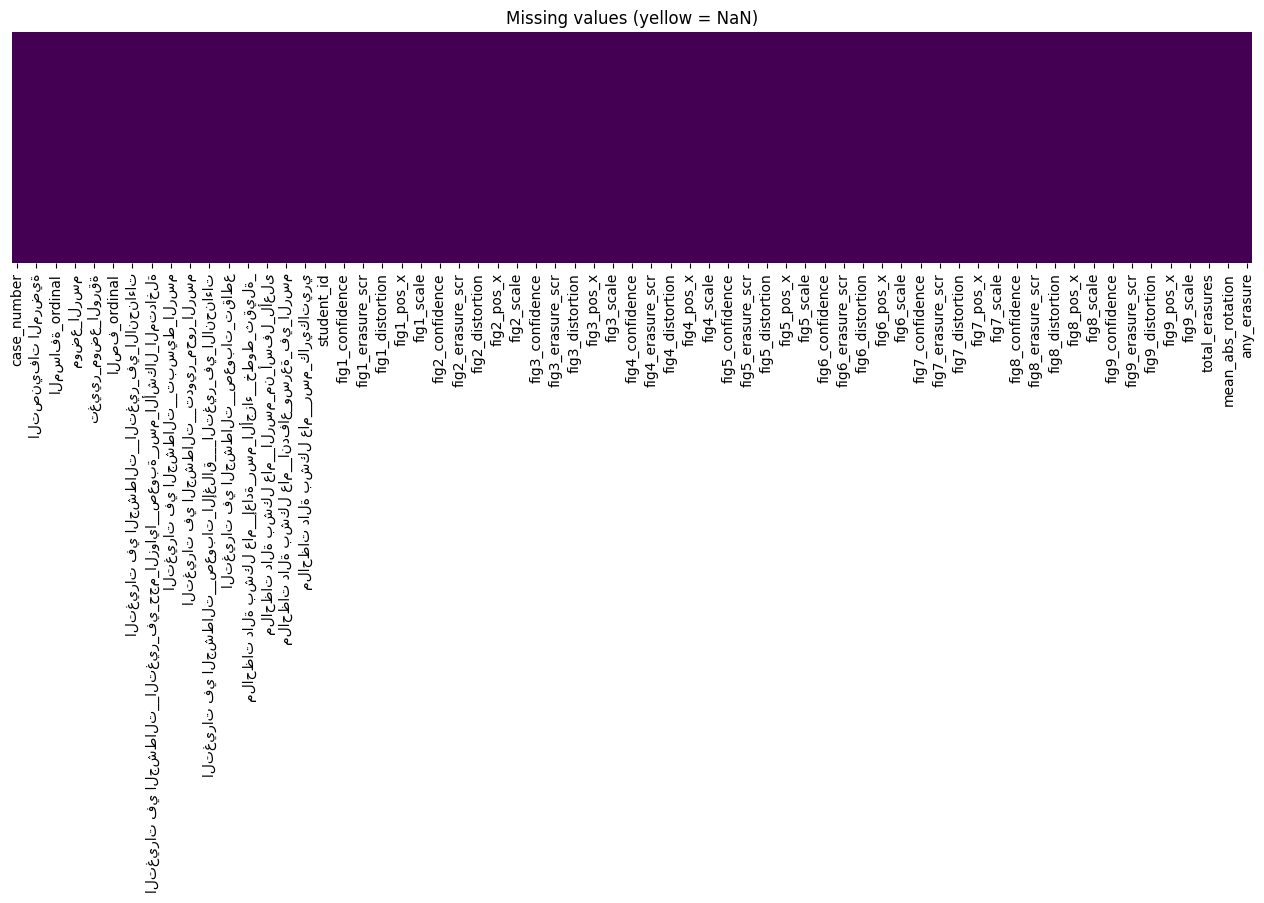

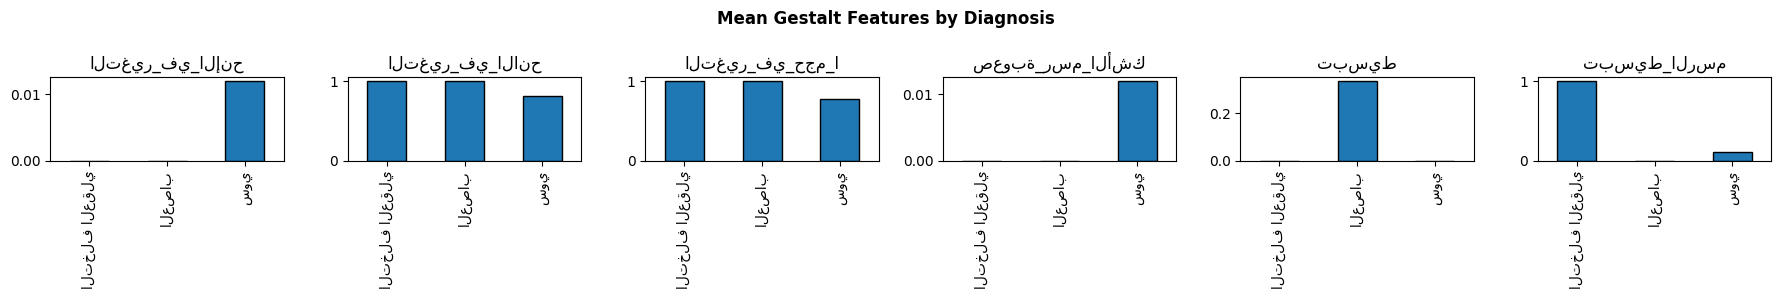

In [12]:
TARGET = 'التصنيفات المرضية'

plt.figure(figsize=(16, 3))
sns.heatmap(df_full.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing values (yellow = NaN)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'missing_values.png'), dpi=150)
plt.show()

gestalt_flags = [c for c in df_full.columns if 'التغيرات في الجشطالت' in c]
if gestalt_flags:
    fig, axes = plt.subplots(1, len(gestalt_flags[:6]), figsize=(18, 3))
    for ax, col in zip(axes, gestalt_flags[:6]):
        df_full.groupby(TARGET)[col].mean().plot(kind='bar', ax=ax,
                                                  title=col.split('__')[-1][:15],
                                                  edgecolor='black')
        ax.set_xlabel('')
    plt.suptitle('Mean Gestalt Features by Diagnosis', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gestalt_by_class.png'), dpi=150)
    plt.show()

## Preprocessing

In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.impute           import SimpleImputer

TARGET = 'التصنيفات المرضية'

drop_cols = [TARGET, 'case_number', 'student_id', 'رقم الحالة']
drop_cols = [c for c in drop_cols if c in df_full.columns]

X_raw = df_full.drop(columns=drop_cols)
y_raw = df_full[TARGET].str.strip()

X_raw = pd.get_dummies(X_raw)

le = LabelEncoder()
y  = le.fit_transform(y_raw.astype(str))
print('Classes       :', list(le.classes_))
print('Class counts  :', Counter(y))
print('Feature count :', X_raw.shape[1])

imputer   = SimpleImputer(strategy='median')
scaler    = StandardScaler()
X_imputed = imputer.fit_transform(X_raw)
X_scaled  = scaler.fit_transform(X_imputed)
feat_names = list(X_raw.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Classes       : ['التخلف العقلي', 'العصاب', 'سوي']
Class counts  : Counter({np.int64(2): 84, np.int64(1): 3, np.int64(0): 2})
Feature count : 126
Train: 71  |  Test: 18


In [14]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE:', Counter(y_train))
min_samples = min(Counter(y_train).values())

if min_samples >= 2:
    k = min(min_samples - 1, 5)
    sm = SMOTE(random_state=42, k_neighbors=k)
    X_tr, y_tr = sm.fit_resample(X_train, y_train)
    print('After  SMOTE:', Counter(y_tr))
else:
    X_tr, y_tr = X_train, y_train
    print('Too few minority samples for SMOTE — using class_weight instead.')

Before SMOTE: Counter({np.int64(2): 67, np.int64(0): 2, np.int64(1): 2})
After  SMOTE: Counter({np.int64(2): 67, np.int64(0): 67, np.int64(1): 67})


## Train and Evaluate models


  Logistic Regression
  Accuracy : 1.0000
  F1 Macro : 1.0000
  ROC-AUC  : nan
               precision    recall  f1-score   support

التخلف العقلي       0.00      0.00      0.00         0
       العصاب       1.00      1.00      1.00         1
          سوي       1.00      1.00      1.00        17

     accuracy                           1.00        18
    macro avg       0.67      0.67      0.67        18
 weighted avg       1.00      1.00      1.00        18



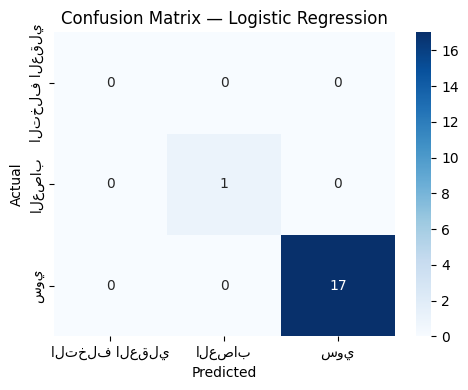


  Random Forest
  Accuracy : 0.9444
  F1 Macro : 0.4857
  ROC-AUC  : nan
               precision    recall  f1-score   support

التخلف العقلي       0.00      0.00      0.00         0
       العصاب       0.00      0.00      0.00         1
          سوي       0.94      1.00      0.97        17

     accuracy                           0.94        18
    macro avg       0.31      0.33      0.32        18
 weighted avg       0.89      0.94      0.92        18



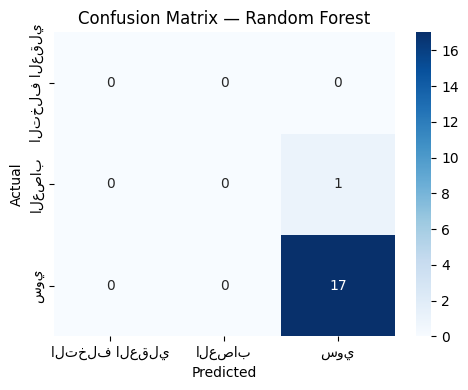


  SVM RBF
  Accuracy : 0.9444
  F1 Macro : 0.4857
  ROC-AUC  : nan
               precision    recall  f1-score   support

التخلف العقلي       0.00      0.00      0.00         0
       العصاب       0.00      0.00      0.00         1
          سوي       0.94      1.00      0.97        17

     accuracy                           0.94        18
    macro avg       0.31      0.33      0.32        18
 weighted avg       0.89      0.94      0.92        18



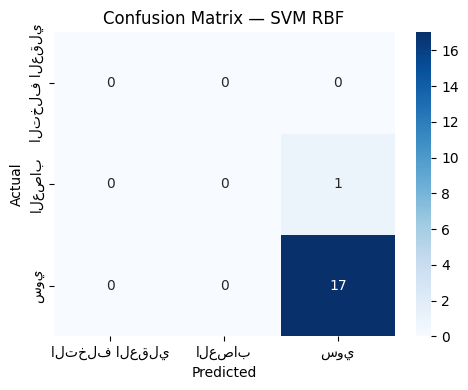


  XGBoost
  Accuracy : 1.0000
  F1 Macro : 1.0000
  ROC-AUC  : nan
               precision    recall  f1-score   support

التخلف العقلي       0.00      0.00      0.00         0
       العصاب       1.00      1.00      1.00         1
          سوي       1.00      1.00      1.00        17

     accuracy                           1.00        18
    macro avg       0.67      0.67      0.67        18
 weighted avg       1.00      1.00      1.00        18



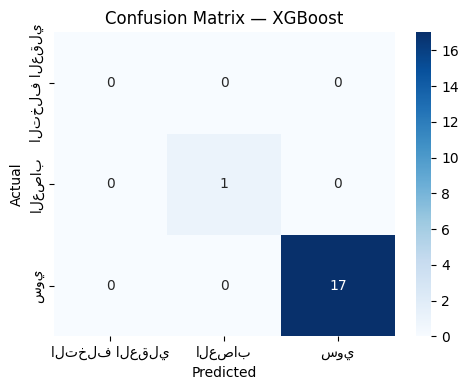

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM
  Accuracy : 1.0000
  F1 Macro : 1.0000
  ROC-AUC  : nan
               precision    recall  f1-score   support

التخلف العقلي       0.00      0.00      0.00         0
       العصاب       1.00      1.00      1.00         1
          سوي       1.00      1.00      1.00        17

     accuracy                           1.00        18
    macro avg       0.67      0.67      0.67        18
 weighted avg       1.00      1.00      1.00        18



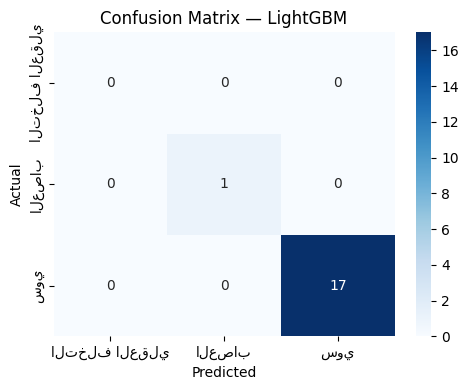

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.svm           import SVC
from xgboost               import XGBClassifier
from lightgbm              import LGBMClassifier
from sklearn.metrics       import (accuracy_score, f1_score,
                                    confusion_matrix, roc_auc_score,
                                    classification_report)

label_names = [str(c) for c in le.classes_]

def eval_model(model, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred, average='macro', zero_division=0)

    try:
        prob = model.predict_proba(X_test)
        auc  = roc_auc_score(y_test, prob, multi_class='ovr',
                             average='macro') if len(le.classes_) > 2 else \
               roc_auc_score(y_test, prob[:,1])
    except Exception:
        auc = float('nan')

    print(f'\n{'='*55}\n  {name}\n{'='*55}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Macro : {f1:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, pred, labels=le.transform(le.classes_), target_names=label_names, zero_division=0))

    cm = confusion_matrix(y_test, pred, labels=le.transform(le.classes_))
    fig, ax = plt.subplots(figsize=(max(5, len(label_names)), max(4, len(label_names))))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    fname = name.replace(' ','_')
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{fname}.png'), dpi=150)
    plt.show()

    return {'name': name, 'model': model, 'accuracy': acc, 'f1_macro': f1, 'roc_auc': auc}


results = []

results.append(eval_model(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Logistic Regression'
))

results.append(eval_model(
    RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=42, n_jobs=-1),
    'Random Forest'
))

results.append(eval_model(
    SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
        probability=True, random_state=42),
    'SVM RBF'
))

results.append(eval_model(
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'XGBoost'
))

results.append(eval_model(
    LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    class_weight='balanced', random_state=42,
                    n_jobs=-1, verbose=-1),
    'LightGBM'
))

## Cross-validation (Leave-One-Out / 5-fold)

In [16]:
from sklearn.model_selection import LeaveOneOut

cv_model = LGBMClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)

if len(X_scaled) <= 89:
    print('Using Leave-One-Out CV (89 samples)...')
    loo    = LeaveOneOut()
    scores = cross_val_score(cv_model, X_scaled, y,
                              cv=loo, scoring='f1_macro', n_jobs=-1)
else:
    print('Using 5-Fold Stratified CV...')
    skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(cv_model, X_scaled, y,
                              cv=skf, scoring='f1_macro', n_jobs=-1)

print(f'CV F1 Macro  — mean: {scores.mean():.4f}  std: {scores.std():.4f}')

Using Leave-One-Out CV (89 samples)...
CV F1 Macro  — mean: 0.9101  std: 0.2860


##  Model comparison summary

              Model  Accuracy  F1 Macro  ROC-AUC
Logistic Regression    1.0000    1.0000      NaN
           LightGBM    1.0000    1.0000      NaN
            XGBoost    1.0000    1.0000      NaN
            SVM RBF    0.9444    0.4857      NaN
      Random Forest    0.9444    0.4857      NaN


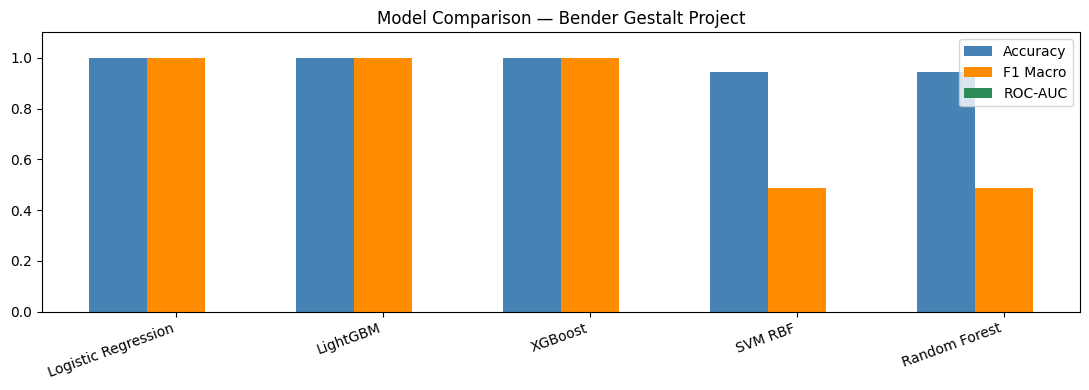

In [17]:
res_df = pd.DataFrame([
    {'Model': r['name'],
     'Accuracy': round(r['accuracy'], 4),
     'F1 Macro': round(r['f1_macro'], 4),
     'ROC-AUC':  round(r.get('roc_auc', float('nan')), 4)}
    for r in results
]).sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print(res_df.to_string(index=False))
res_df.to_excel(os.path.join(OUTPUT_DIR, 'model_results.xlsx'), index=False)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(res_df)); w = 0.28
ax.bar(x-w, res_df['Accuracy'], w, label='Accuracy',  color='steelblue')
ax.bar(x,   res_df['F1 Macro'], w, label='F1 Macro',  color='darkorange')
ax.bar(x+w, res_df['ROC-AUC'],  w, label='ROC-AUC',   color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(res_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.1); ax.legend()
ax.set_title('Model Comparison — Bender Gestalt Project')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'model_comparison.png'), dpi=150)
plt.show()

##  SHAP Explainability

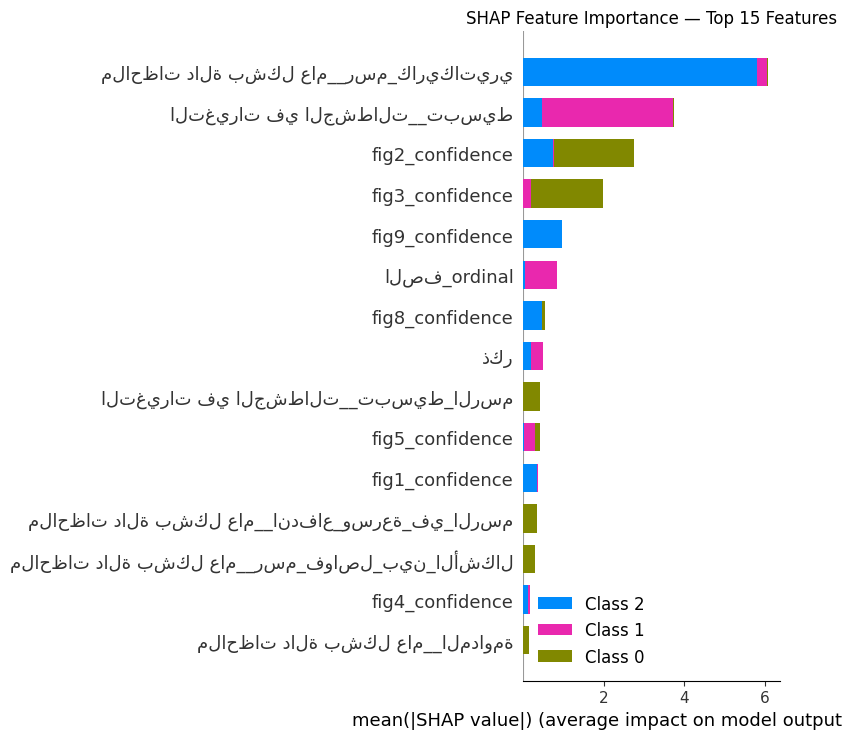

In [18]:
import shap

shap_model = LGBMClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
shap_model.fit(X_tr, y_tr)

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

sv = shap_values[0] if isinstance(shap_values, list) else shap_values
shap.summary_plot(
    sv, X_test,
    feature_names=feat_names[:X_test.shape[1]],
    plot_type='bar', max_display=15, show=False
)
plt.title('SHAP Feature Importance — Top 15 Features')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'shap_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

##  Save models & final outputs

In [19]:
import joblib

best = res_df.iloc[0]
print(f'Best model : {best["Model"]}  (F1 Macro = {best["F1 Macro"]})')

# Save best sklearn model
sklearn_map = {r['name']: r.get('model') for r in results}
best_obj    = sklearn_map.get(best['Model'])
if best_obj and not isinstance(best_obj, torch.nn.Module):
    path = os.path.join(OUTPUT_DIR, f'best_model.pkl')
    joblib.dump(best_obj, path)
    print(f'  Saved sklearn model → {path}')

# Save preprocessing objects
joblib.dump(le,      os.path.join(OUTPUT_DIR, 'label_encoder.pkl'))
joblib.dump(scaler,  os.path.join(OUTPUT_DIR, 'scaler.pkl'))
joblib.dump(imputer, os.path.join(OUTPUT_DIR, 'imputer.pkl'))

print('\n── All output files ──')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

Best model : Logistic Regression  (F1 Macro = 1.0)
  Saved sklearn model → /content/drive/MyDrive/BenderTest/outputs/best_model.pkl

── All output files ──
  best_model.pkl
  class_dist.png
  cm_LightGBM.png
  cm_Logistic_Regression.png
  cm_Random_Forest.png
  cm_SVM_RBF.png
  cm_XGBoost.png
  gestalt_by_class.png
  imputer.pkl
  label_encoder.pkl
  missing_values.png
  model_comparison.png
  model_results.xlsx
  part1_engineered_features.xlsx
  sample_drawings.png
  scaler.pkl
  shap_importance.png
